# Evaluation

This notebook evaluates the final DNABERT deep ensemble on the held-out GUIDE-seq and CHANGE-seq test sets. The analysis focuses on three aspects of model behaviour: predictive discrimination, probability calibration, and uncertainty under cross-dataset distribution shift.

First, the ensemble is compared with the baseline models using AUROC, AUPRC, Brier score, and top-k enrichment. Calibration is then assessed before and after correcting for the negative undersampling used during training, using ECE, Brier decomposition, and reliability diagrams. Ensemble disagreement is evaluated as a proxy for epistemic uncertainty by examining its relationship with prediction error and through coverage-risk analysis. Finally, gRNA-level cluster bootstrap confidence intervals are used to quantify uncertainty in the main evaluation metrics while accounting for dependence between candidate sites from the same guide.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss)
from scipy.special import expit

In [2]:
os.makedirs('results/', exist_ok=True)

In [3]:
DATA_DIR = 'data/processed/'

# Loads the final test data
guide_test_df = pd.read_csv(DATA_DIR + 'guide_test.csv', low_memory=False)
change_test_df = pd.read_csv(DATA_DIR + 'change_test.csv', low_memory=False)

# Labels in exactly the same row order used for ensemble inference
y_guide_test = guide_test_df['label'].to_numpy()
y_change_test = change_test_df['label'].to_numpy()

# Loads the final retrained ensemble logits
guide_logits = np.load(DATA_DIR + 'guide_member_logits.npy')
change_logits = np.load(DATA_DIR + 'change_member_logits.npy')

# Loads the negative-sampling metadata saved during ensemble training
metadata = np.load(DATA_DIR + 'ensemble_training_metadata.npz')

negative_sampling_rate = float(metadata['negative_sampling_rate'])
OFFSET = float(metadata['sampling_logit_offset'])

# Basic alignment checks
assert guide_logits.shape == (5, len(y_guide_test))
assert change_logits.shape == (5, len(y_change_test))

assert np.isfinite(guide_logits).all()
assert np.isfinite(change_logits).all()

# Raw member probabilities
guide_member_raw = expit(guide_logits)
change_member_raw = expit(change_logits)

guide_raw = guide_member_raw.mean(axis=0)
change_raw = change_member_raw.mean(axis=0)

# Corrects each ensemble member before aggregation
guide_member_probs = expit(guide_logits + OFFSET)
change_member_probs = expit(change_logits + OFFSET)

guide_mean_probs = guide_member_probs.mean(axis=0)
change_mean_probs = change_member_probs.mean(axis=0)

# Ensemble variance is used as proxy for epistemic uncertainty
guide_uncertainty = guide_member_probs.var(axis=0)
change_uncertainty = change_member_probs.var(axis=0)

print(f'GUIDE logits: {guide_logits.shape}')
print(f'CHANGE logits: {change_logits.shape}')

print(f'\nTraining positives: {int(metadata["n_positive"]):,}')
print(f'Negative sampling rate: {negative_sampling_rate:.8f}')
print(f'Logit correction offset: {OFFSET:.6f}')

print(f'\nGUIDE prevalence: {y_guide_test.mean():.6f}')
print(f'GUIDE raw mean prediction: {guide_raw.mean():.6f}')
print(f'GUIDE corrected mean prediction: {guide_mean_probs.mean():.6f}')

print(f'\nCHANGE prevalence: {y_change_test.mean():.6f}')
print(f'CHANGE raw mean prediction: {change_raw.mean():.6f}')
print(f'CHANGE corrected mean prediction: {change_mean_probs.mean():.6f}')

GUIDE logits: (5, 248614)
CHANGE logits: (5, 520991)

Training positives: 1,371
Negative sampling rate: 0.01116652
Logit correction offset: -4.494835

GUIDE prevalence: 0.000362
GUIDE raw mean prediction: 0.032294
GUIDE corrected mean prediction: 0.000391

CHANGE prevalence: 0.012687
CHANGE raw mean prediction: 0.034426
CHANGE corrected mean prediction: 0.000419


In [4]:
# Expected Calibration Error using either quantile or uniform-width bins
def ece(y, p, n_bins=10, strategy='quantile'):
    if strategy == 'quantile':
        # Quantile bins contain roughly equal numbers of predictions
        edges = np.unique(
            np.quantile(p, np.linspace(0, 1, n_bins + 1))
        )
    else:
        edges = np.linspace(0, 1, n_bins + 1)

    # Assigns each prediction to a calibration bin
    idx = np.clip(
        np.digitize(p, edges[1:-1], right=False),
        0,
        len(edges) - 2
    )
    total = 0.0
    for b in range(len(edges) - 1):
        mask = idx == b
        if not mask.any():
            continue
        # Weighted difference between mean confidence and observed frequency
        total += (
            mask.mean()
            * abs(p[mask].mean() - y[mask].mean())
        )
    return total


# Murphy decomposition of the Brier score
def brier_decomp(y, p, n_bins=10):
    # Quantile bins used because predicted probabilities are highly concentrated
    edges = np.unique(
        np.quantile(p, np.linspace(0, 1, n_bins + 1))
    )
    idx = np.clip(
        np.digitize(p, edges[1:-1], right=False),
        0,
        len(edges) - 2
    )
    ybar = y.mean()
    n = len(y)

    reliability = 0.0
    resolution = 0.0

    for b in range(len(edges) - 1):
        mask = idx == b
        if not mask.any():
            continue
        weight = mask.sum() / n
        # Calibration error within the bin
        reliability += (
            weight
            * (p[mask].mean() - y[mask].mean()) ** 2
        )
        # How much the observed bin rate differs from overall prevalence
        resolution += (
            weight
            * (y[mask].mean() - ybar) ** 2
        )
    return {
        'brier': np.mean((p - y) ** 2),
        'reliability': reliability,
        'resolution': resolution,
        'uncertainty': ybar * (1 - ybar)
    }

## Performance Metrics

In [5]:
# Metrics for the ensemble
for name, y, p in [
    ('GUIDE-seq (within-dataset)', y_guide_test, guide_mean_probs),
    ('CHANGE-seq (cross-dataset)', y_change_test, change_mean_probs)
]:
    print(name)
    print(f'AUROC: {roc_auc_score(y, p):.4f}')
    print(f'AUPRC: {average_precision_score(y, p):.4f}')
    print(f'Brier score: {brier_score_loss(y, p):.6f}')
    print(f'Prevalence: {y.mean():.6f}')
    print()

GUIDE-seq (within-dataset)
AUROC: 0.8577
AUPRC: 0.0117
Brier score: 0.000361
Prevalence: 0.000362

CHANGE-seq (cross-dataset)
AUROC: 0.8588
AUPRC: 0.1015
Brier score: 0.012656
Prevalence: 0.012687



In [6]:
# Comparing the final ensemble against the baseline models
results = {
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Neural Network',
        'DNABERT Ensemble'
    ],
    'GUIDE AUROC': [
        0.6471,
        0.4954,
        0.6818,
        roc_auc_score(y_guide_test, guide_mean_probs)
    ],
    'GUIDE AUPRC': [
        0.0005,
        0.0004,
        0.0007,
        average_precision_score(y_guide_test, guide_mean_probs)
    ],
    'CHANGE AUROC': [
        0.8612,
        0.5576,
        0.7850,
        roc_auc_score(y_change_test, change_mean_probs)
    ],
    'CHANGE AUPRC': [
        0.0840,
        0.0461,
        0.1115,
        average_precision_score(y_change_test, change_mean_probs)
    ]
}

performance_df = pd.DataFrame(results)

performance_df.style.format({
    'GUIDE AUROC': '{:.4f}',
    'GUIDE AUPRC': '{:.4f}',
    'CHANGE AUROC': '{:.4f}',
    'CHANGE AUPRC': '{:.4f}'
})

,Model,GUIDE AUROC,GUIDE AUPRC,CHANGE AUROC,CHANGE AUPRC
0,Logistic Regression,0.6471,0.0005,0.8612,0.0840
1,Random Forest,0.4954,0.0004,0.5576,0.0461
2,Neural Network,0.6818,0.0007,0.7850,0.1115
3,DNABERT Ensemble,0.8577,0.0117,0.8588,0.1015


In [7]:
# Evaluates how strongly true off-targets are concentrated at the top of the ranking
guide_ranked_idx = np.argsort(guide_mean_probs)[::-1]
change_ranked_idx = np.argsort(change_mean_probs)[::-1]

rows = []

for k in [10, 50, 100, 500]:
    guide_top_k = y_guide_test[guide_ranked_idx[:k]]
    change_top_k = y_change_test[change_ranked_idx[:k]]

    guide_precision = guide_top_k.mean()
    guide_recall = guide_top_k.sum() / y_guide_test.sum()

    change_precision = change_top_k.mean()
    change_recall = change_top_k.sum() / y_change_test.sum()

    rows.append({
        'Top-k': k,

        'GUIDE Precision (%)': round(guide_precision * 100, 2),
        'GUIDE Recall (%)': round(guide_recall * 100, 2),
        'GUIDE Enrichment': round(
            guide_precision / y_guide_test.mean(), 1
        ),

        'CHANGE Precision (%)': round(change_precision * 100, 2),
        'CHANGE Recall (%)': round(change_recall * 100, 2),
        'CHANGE Enrichment': round(
            change_precision / y_change_test.mean(), 1
        )
    })

topk_df = pd.DataFrame(rows)
topk_df

,Top-k,GUIDE Precision (%),GUIDE Recall (%),GUIDE Enrichment,CHANGE Precision (%),CHANGE Recall (%),CHANGE Enrichment
0,10,0.0,0.00,0.0,40.0,0.06,31.5
1,50,2.0,1.11,55.2,42.0,0.32,33.1
2,100,4.0,4.44,110.5,45.0,0.68,35.5
3,500,2.8,15.56,77.3,36.4,2.75,28.7


### Results

The DNABERT ensemble achieved higher AUROC and AUPRC than all baseline models on GUIDE-seq, with AUROC of 0.8577 and AUPRC of 0.0117. On CHANGE-seq, logistic regression achieved a slightly higher AUROC and the neural network a higher AUPRC. The ensemble nevertheless strongly enriched true off-targets near the top of its ranking, reaching 110.5× enrichment within the top 100 GUIDE-seq predictions and 35.5× enrichment on CHANGE-seq. Overall, ranking performance is largely maintained across datasets despite substantial deterioration in probability calibration.

## Calibration and ECE

In [8]:
for nm, logits, y in [('GUIDE',  guide_logits,  y_guide_test),
                      ('CHANGE', change_logits, y_change_test)]:
    corr = expit(logits + OFFSET)
    eces = [ece(y, corr[i]) for i in range(corr.shape[0])]

    print(f'{nm} (prior-corrected, quantile ECE):')
    for i, e in enumerate(eces, 1):
        print(f'member {i}: ECE={e:.6f} mean pred={corr[i-1].mean():.6f}')
    print(f'mean member: {np.mean(eces):.6f}')
    print(f'best member: {min(eces):.6f}')
    print(f'ENSEMBLE: {ece(y, corr.mean(axis=0)):.6f}\n')

GUIDE (prior-corrected, quantile ECE):
member 1: ECE=0.000174 mean pred=0.000399
member 2: ECE=0.000157 mean pred=0.000454
member 3: ECE=0.000135 mean pred=0.000359
member 4: ECE=0.000155 mean pred=0.000377
member 5: ECE=0.000212 mean pred=0.000365
mean member: 0.000167
best member: 0.000135
ENSEMBLE: 0.000235

CHANGE (prior-corrected, quantile ECE):
member 1: ECE=0.012351 mean pred=0.000336
member 2: ECE=0.012179 mean pred=0.000508
member 3: ECE=0.012319 mean pred=0.000368
member 4: ECE=0.012200 mean pred=0.000487
member 5: ECE=0.012290 mean pred=0.000397
mean member: 0.012268
best member: 0.012179
ENSEMBLE: 0.012268



### Results

All five ensemble members show substantially higher calibration error on CHANGE-seq than on GUIDE-seq. Ensemble averaging does not remove this deterioration, suggesting that the calibration failure is shared across members rather than being driven by a single poorly calibrated model.

In [9]:
# Compares calibration before and after correcting for negative undersampling
rows = []

for dataset, probs, y, version in [
    ('GUIDE', guide_raw, y_guide_test, 'raw'),
    ('GUIDE', guide_mean_probs, y_guide_test, 'corrected'),
    ('CHANGE', change_raw, y_change_test, 'raw'),
    ('CHANGE', change_mean_probs, y_change_test, 'corrected')
]:
    decomposition = brier_decomp(y, probs)

    rows.append({
        'Dataset': dataset,
        'Probabilities': version,
        'Mean prediction': probs.mean(),
        'Prevalence': y.mean(),
        'ECE (uniform)': ece(y, probs, strategy='uniform'),
        'ECE (quantile)': ece(y, probs, strategy='quantile'),
        'Brier score': decomposition['brier'],
        'Zero-predictor Brier': y.mean(),
        'Reliability': decomposition['reliability'],
        'Resolution': decomposition['resolution']
    })

calibration_df = pd.DataFrame(rows)

calibration_df.style.format({
    'Mean prediction': '{:.6f}',
    'Prevalence': '{:.6f}',
    'ECE (uniform)': '{:.6f}',
    'ECE (quantile)': '{:.6f}',
    'Brier score': '{:.6f}',
    'Zero-predictor Brier': '{:.6f}',
    'Reliability': '{:.8f}',
    'Resolution': '{:.8f}'
})

,Dataset,Probabilities,Mean prediction,Prevalence,ECE (uniform),ECE (quantile),Brier score,Zero-predictor Brier,Reliability,Resolution
0,GUIDE,raw,0.032294,0.000362,0.031932,0.031932,0.002184,0.000362,0.00167588,0.00000048
1,GUIDE,corrected,0.000391,0.000362,0.000029,0.000235,0.000361,0.000362,0.00000013,0.00000046
2,CHANGE,raw,0.034426,0.012687,0.021984,0.021739,0.012505,0.012687,0.00056274,0.00040473
3,CHANGE,corrected,0.000419,0.012687,0.012268,0.012268,0.012656,0.012687,0.00054084,0.00040566


### Results
Correcting for negative undersampling substantially improved calibration on GUIDE-seq, reducing quantile ECE from 0.031932 to 0.000235 and bringing the mean predicted probability (0.000391) close to the observed prevalence (0.000362). On CHANGE-seq, the same correction reduced ECE from 0.021739 to 0.012268, but the corrected mean prediction (0.000419) remained far below the observed prevalence (0.012687). This indicates that the sampling correction successfully removes the known training-prior distortion but does not preserve probability calibration under cross-dataset shift.

### Reliability Diagrams

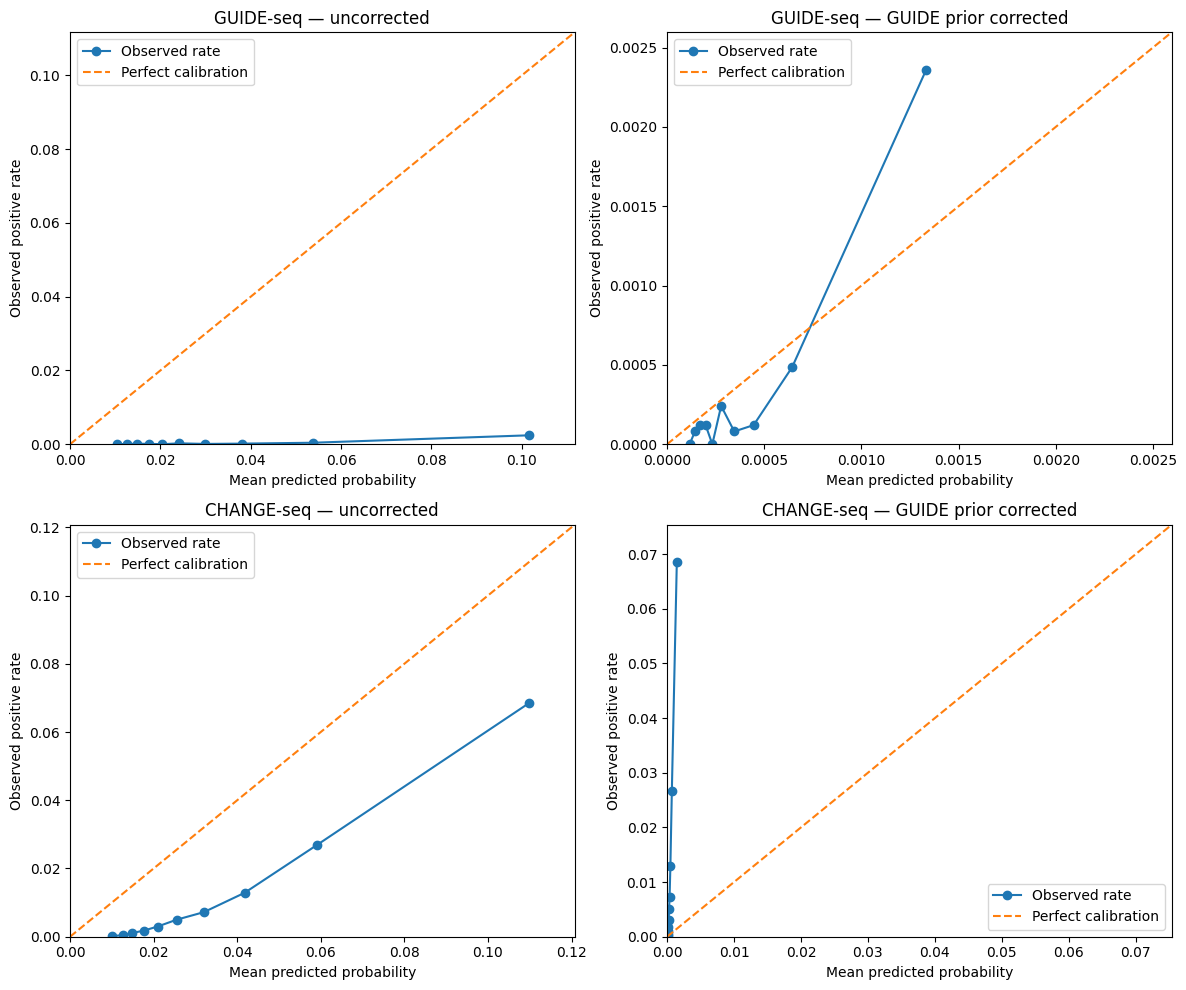

In [10]:
# Reliability diagrams before and after correcting for negative undersampling
def reliability_stats(y_true, y_prob, n_bins=10):
    edges = np.quantile(y_prob, np.linspace(0, 1, n_bins + 1))
    edges = np.unique(edges)

    rows = []
    for i in range(len(edges) - 1):
        if i == len(edges) - 2:
            mask = (y_prob >= edges[i]) & (y_prob <= edges[i + 1])
        else:
            mask = (y_prob >= edges[i]) & (y_prob < edges[i + 1])
        if not mask.any():
            continue
        rows.append({
            'mean_pred': y_prob[mask].mean(),
            'observed': y_true[mask].mean(),
            'n': mask.sum()
        })
    return pd.DataFrame(rows)


def plot_reliability(ax, y_true, y_prob, title, n_bins=10):
    stats_df = reliability_stats(y_true, y_prob, n_bins)

    ax.plot(
        stats_df['mean_pred'],
        stats_df['observed'],
        marker='o',
        label='Observed rate'
    )

    limit = max(
        stats_df['mean_pred'].max(),
        stats_df['observed'].max()
    ) * 1.1

    ax.plot(
        [0, limit],
        [0, limit],
        linestyle='--',
        label='Perfect calibration'
    )

    ax.set_xlim(0, limit)
    ax.set_ylim(0, limit)
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Observed positive rate')
    ax.set_title(title)
    ax.legend()


fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_reliability(
    axes[0, 0],
    y_guide_test,
    guide_raw,
    'GUIDE-seq — uncorrected'
)

plot_reliability(
    axes[0, 1],
    y_guide_test,
    guide_mean_probs,
    'GUIDE-seq — GUIDE prior corrected'
)

plot_reliability(
    axes[1, 0],
    y_change_test,
    change_raw,
    'CHANGE-seq — uncorrected'
)

plot_reliability(
    axes[1, 1],
    y_change_test,
    change_mean_probs,
    'CHANGE-seq — GUIDE prior corrected'
)

plt.tight_layout()

plt.savefig(
    'results/reliability_raw_vs_corrected.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Results
- Prior correction substantially improved GUIDE-seq calibration, reducing quantile ECE from 0.031932 to 0.000235.
- CHANGE-seq calibration also improved, but remained poor, with corrected ECE of 0.012268.
- The reliability diagrams show that prior correction largely restores GUIDE-seq calibration, but CHANGE-seq probabilities still systematically underpredict the observed positive rate.

## Uncertainty Analysis

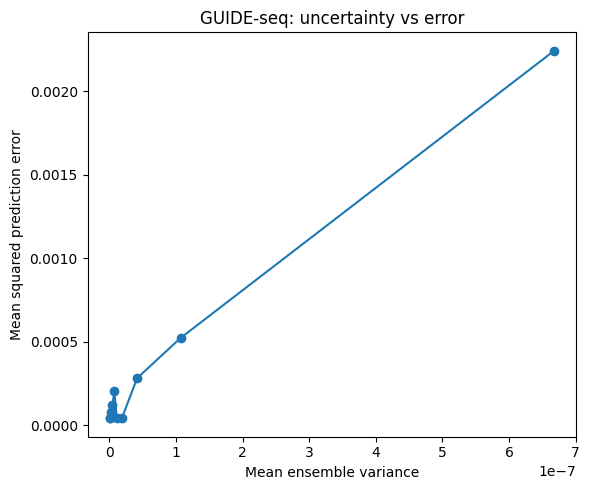

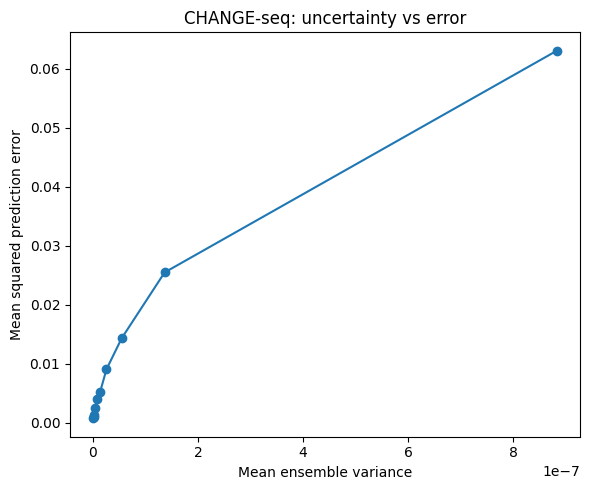

In [11]:
# Testing whether greater ensemble disagreement is associated with greater error
def uncertainty_error_bins(y_true, y_prob, uncertainty, n_bins=10):
    edges = np.unique(
        np.quantile(uncertainty, np.linspace(0, 1, n_bins + 1))
    )

    rows = []
    for i in range(len(edges) - 1):
        if i == len(edges) - 2:
            mask = (
                (uncertainty >= edges[i]) &
                (uncertainty <= edges[i + 1])
            )
        else:
            mask = (
                (uncertainty >= edges[i]) &
                (uncertainty < edges[i + 1])
            )
        if not mask.any():
            continue
        squared_error = (y_true[mask] - y_prob[mask]) ** 2
        rows.append({
            'mean_uncertainty': uncertainty[mask].mean(),
            'mean_error': squared_error.mean(),
            'n': mask.sum()
        })
    return pd.DataFrame(rows)

guide_unc_df = uncertainty_error_bins(
    y_guide_test,
    guide_mean_probs,
    guide_uncertainty
)

change_unc_df = uncertainty_error_bins(
    y_change_test,
    change_mean_probs,
    change_uncertainty
)

plt.figure(figsize=(6, 5))
plt.plot(
    guide_unc_df['mean_uncertainty'],
    guide_unc_df['mean_error'],
    marker='o'
)
plt.xlabel('Mean ensemble variance')
plt.ylabel('Mean squared prediction error')
plt.title('GUIDE-seq: uncertainty vs error')
plt.tight_layout()

plt.savefig(
    'results/guide_uncertainty_analysis.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


plt.figure(figsize=(6, 5))
plt.plot(
    change_unc_df['mean_uncertainty'],
    change_unc_df['mean_error'],
    marker='o'
)
plt.xlabel('Mean ensemble variance')
plt.ylabel('Mean squared prediction error')
plt.title('CHANGE-seq: uncertainty vs error')
plt.tight_layout()

plt.savefig(
    'results/change_uncertainty_analysis.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Results

- Mean prediction error generally increases with ensemble disagreement on both datasets.
- This relationship persists on CHANGE-seq despite the deterioration in probability calibration.
- The result suggests that ensemble variance may still provide useful information about prediction reliability under shift, which is examined further using coverage-risk analysis.

## Coverage Risk Curves

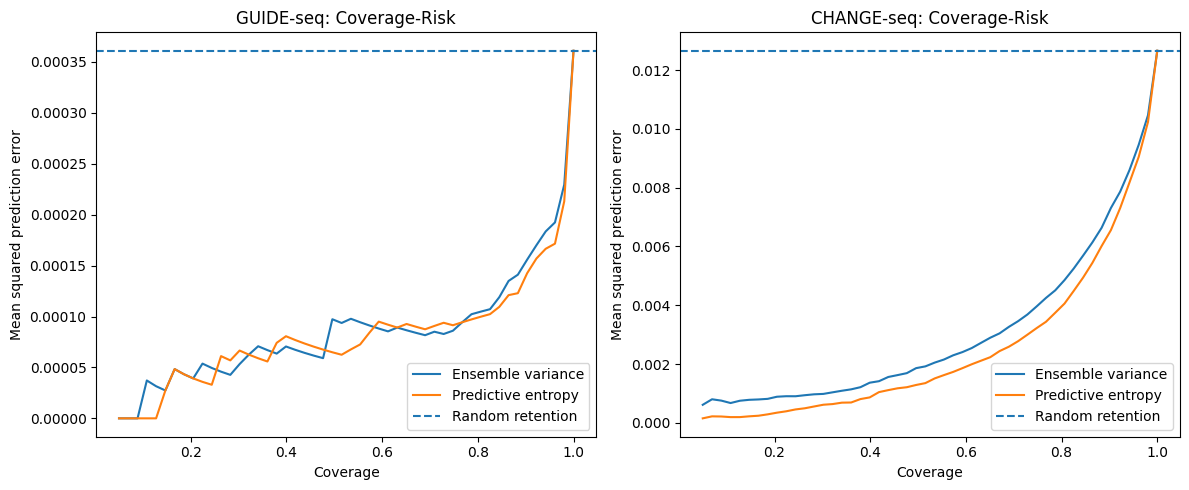

GUIDE
Variance AURC: 0.000082
Entropy AURC: 0.000077
Full risk: 0.000361

CHANGE
Variance AURC: 0.002889
Entropy AURC: 0.002370
Full risk: 0.012656

100% coverage sanity check
GUIDE: 0.000361
CHANGE: 0.012656


In [12]:
# Retains the least uncertain predictions first and measures prediction error
def coverage_risk_curve(y_true, y_prob, uncertainty, n_points=50):
    order = np.argsort(uncertainty)

    errors = (y_true[order] - y_prob[order]) ** 2
    cumulative_error = np.cumsum(errors)

    coverages = np.linspace(0.05, 1.0, n_points)
    risks = []
    for coverage in coverages:
        n_keep = max(1, int(len(y_true) * coverage))
        risks.append(cumulative_error[n_keep - 1] / n_keep)
    return coverages, np.array(risks)

# Predictive entropy provides a simple confidence-based comparison
def predictive_entropy(p):
    p = np.clip(p, 1e-12, 1 - 1e-12)
    return -(p * np.log(p) + (1 - p) * np.log(1 - p))

guide_entropy = predictive_entropy(guide_mean_probs)
change_entropy = predictive_entropy(change_mean_probs)

guide_cov, guide_var_risk = coverage_risk_curve(
    y_guide_test,
    guide_mean_probs,
    guide_uncertainty
)

_, guide_entropy_risk = coverage_risk_curve(
    y_guide_test,
    guide_mean_probs,
    guide_entropy
)

change_cov, change_var_risk = coverage_risk_curve(
    y_change_test,
    change_mean_probs,
    change_uncertainty
)

_, change_entropy_risk = coverage_risk_curve(
    y_change_test,
    change_mean_probs,
    change_entropy
)

# Random rejection is expected to retain the overall dataset risk
guide_random_risk = np.mean(
    (y_guide_test - guide_mean_probs) ** 2
)

change_random_risk = np.mean(
    (y_change_test - change_mean_probs) ** 2
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(
    guide_cov,
    guide_var_risk,
    label='Ensemble variance'
)
axes[0].plot(
    guide_cov,
    guide_entropy_risk,
    label='Predictive entropy'
)
axes[0].axhline(
    guide_random_risk,
    linestyle='--',
    label='Random retention'
)
axes[0].set_xlabel('Coverage')
axes[0].set_ylabel('Mean squared prediction error')
axes[0].set_title('GUIDE-seq: Coverage-Risk')
axes[0].legend()

axes[1].plot(
    change_cov,
    change_var_risk,
    label='Ensemble variance'
)
axes[1].plot(
    change_cov,
    change_entropy_risk,
    label='Predictive entropy'
)
axes[1].axhline(
    change_random_risk,
    linestyle='--',
    label='Random retention'
)
axes[1].set_xlabel('Coverage')
axes[1].set_ylabel('Mean squared prediction error')
axes[1].set_title('CHANGE-seq: Coverage-Risk')
axes[1].legend()

plt.tight_layout()

plt.savefig(
    'results/coverage_risk.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Area under each coverage-risk curve
print('GUIDE')
print(f"Variance AURC: {np.trapezoid(guide_var_risk, guide_cov):.6f}")
print(f"Entropy AURC: {np.trapezoid(guide_entropy_risk, guide_cov):.6f}")
print(f"Full risk: {guide_random_risk:.6f}")

print('\nCHANGE')
print(f"Variance AURC: {np.trapezoid(change_var_risk, change_cov):.6f}")
print(f"Entropy AURC: {np.trapezoid(change_entropy_risk, change_cov):.6f}")
print(f"Full risk: {change_random_risk:.6f}")

# At 100% coverage the risk should equal the Brier score
print('\n100% coverage sanity check')
print(f"GUIDE: {guide_var_risk[-1]:.6f}")
print(f"CHANGE: {change_var_risk[-1]:.6f}")

### Results
- Prediction error increases as more uncertain samples are retained on both datasets.
- Ensemble-variance rejection performs substantially better than random retention, indicating that disagreement contains useful reliability information under shift.
- Predictive entropy achieves slightly lower risk than ensemble variance, suggesting that ensemble disagreement is informative but does not outperform simpler confidence-based rejection.

## Cluster Bootstrap Confidence Intervals

In [13]:
# Cluster bootstrap by gRNA for the main evaluation metrics
def cluster_bootstrap_metrics(
    df,
    y_true,
    y_prob,
    cluster_col='target',
    n_boot=1000,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    # Positional row indices belonging to each gRNA
    groups = df.groupby(cluster_col, sort=False).indices
    cluster_ids = np.array(list(groups.keys()), dtype=object)

    boot_rows = []

    for _ in range(n_boot):
        # Resampling whole gRNAs with replacement
        sampled_clusters = rng.choice(
            cluster_ids,
            size=len(cluster_ids),
            replace=True
        )

        idx = np.concatenate([
            groups[g] for g in sampled_clusters
        ])

        y_boot = y_true[idx]
        p_boot = y_prob[idx]

        # AUROC/AUPRC require both classes to be represented
        if np.unique(y_boot).size == 2:
            auroc = roc_auc_score(y_boot, p_boot)
            auprc = average_precision_score(y_boot, p_boot)
        else:
            auroc = np.nan
            auprc = np.nan

        boot_rows.append({
            'AUROC': auroc,
            'AUPRC': auprc,
            'ECE': ece(
                y_boot,
                p_boot,
                n_bins=10,
                strategy='quantile'
            ),
            'Brier': brier_score_loss(y_boot, p_boot)
        })

    boot_df = pd.DataFrame(boot_rows)

    # Metrics on the original, unresampled test set
    point_estimates = {
        'AUROC': roc_auc_score(y_true, y_prob),
        'AUPRC': average_precision_score(y_true, y_prob),
        'ECE': ece(
            y_true,
            y_prob,
            n_bins=10,
            strategy='quantile'
        ),
        'Brier': brier_score_loss(y_true, y_prob)
    }

    summary = []

    for metric, estimate in point_estimates.items():
        values = boot_df[metric].dropna()

        summary.append({
            'Metric': metric,
            'Estimate': estimate,
            '95% CI lower': np.percentile(values, 2.5),
            '95% CI upper': np.percentile(values, 97.5),
            'Valid bootstraps': len(values)
        })

    return pd.DataFrame(summary), boot_df

In [ ]:
guide_ci, guide_boot = cluster_bootstrap_metrics(
    guide_test_df,
    y_guide_test,
    guide_mean_probs,
    n_boot=1000,
    random_state=42
)

change_ci, change_boot = cluster_bootstrap_metrics(
    change_test_df,
    y_change_test,
    change_mean_probs,
    n_boot=1000,
    random_state=42
)

print(
    f"GUIDE test gRNAs: "
    f"{guide_test_df['target'].nunique()}"
)

display(
    guide_ci.style.format({
        'Estimate': '{:.6f}',
        '95% CI lower': '{:.6f}',
        '95% CI upper': '{:.6f}'
    })
)

print(
    f"CHANGE test gRNAs: "
    f"{change_test_df['target'].nunique()}"
)

display(
    change_ci.style.format({
        'Estimate': '{:.6f}',
        '95% CI lower': '{:.6f}',
        '95% CI upper': '{:.6f}'
    })
)

### Results

Cluster bootstrap confidence intervals were estimated by resampling complete gRNAs to account for dependence between candidate sites from the same guide. AUROC remained similar across GUIDE-seq and CHANGE-seq, while calibration error increased substantially under cross-dataset shift. The 95% confidence intervals for ECE did not overlap (0.000112–0.000486 for GUIDE-seq versus 0.003728–0.020714 for CHANGE-seq), supporting the conclusion that discriminative performance is comparatively robust while probability calibration deteriorates under shift.